### Langchain Version V1

### Agents

In [1]:
import langchain
langchain.__version__

'1.3.11'

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")

CREATING AGENT


<div style="font-family: Arial, sans-serif; line-height: 1.6;">

<h1 style="color:#1E3A8A;">Difference Between <code>create_agent</code>, LangGraph Nodes, and DeepAgents</h1>

<p style="font-size:16px;">
When building <b>agentic AI applications</b>, we can create agents at different levels of control and complexity.
The three common approaches are:
</p>

<div style="background-color:#EFF6FF; border-left:6px solid #2563EB; padding:14px; border-radius:8px;">
<b style="color:#1D4ED8;">Main Options:</b>
<ol>
  <li><code>create_agent</code> from LangChain</li>
  <li>Custom agents using LangGraph nodes</li>
  <li>DeepAgents</li>
</ol>
</div>

<hr>

<h2 style="color:#2563EB;">1. <code>create_agent</code> from LangChain</h2>

<div style="background-color:#F0F9FF; border:1px solid #BAE6FD; padding:14px; border-radius:10px;">
<p>
<code>create_agent</code> is the <b>simplest and fastest way</b> to create an agent.
It provides a ready-made agent loop where the LLM can decide which tool to call, use the tool, read the result, and generate the final answer.
</p>
</div>

```python
from langchain.agents import create_agent

agent = create_agent(
    model="gpt-4o-mini",
    tools=[search_tool, calculator_tool],
    system_prompt="You are a helpful assistant"
)
```

<h3 style="color:#0F766E;">How it works</h3>

<div style="background-color:#ECFDF5; border-left:6px solid #10B981; padding:14px; border-radius:8px;">

```text
User Input
   ↓
LLM decides whether a tool is needed
   ↓
Tool is called
   ↓
Tool result is returned to the LLM
   ↓
LLM generates the final answer
```

</div>

<h3 style="color:#9333EA;">Best for</h3>

<ul>
  <li>Simple tool-using chatbots</li>
  <li>Quick prototypes</li>
  <li>Basic AI assistants</li>
  <li>Small workflows</li>
  <li>Cases where you do not need full control over every step</li>
</ul>

<div style="background-color:#FEF3C7; border-left:6px solid #F59E0B; padding:14px; border-radius:8px;">
<b>Example:</b><br>
User asks: <i>“What is the weather in Hyderabad today?”</i><br>
Agent calls the weather tool, gets the result, and replies to the user.
</div>

<hr>

<h2 style="color:#7C3AED;">2. Agent Using LangGraph Nodes</h2>

<div style="background-color:#F5F3FF; border:1px solid #DDD6FE; padding:14px; border-radius:10px;">
<p>
LangGraph is used when we want <b>more control over the agent workflow</b>.
Instead of depending on a ready-made agent loop, we manually design the workflow using:
</p>

<ul>
  <li>Nodes</li>
  <li>Edges</li>
  <li>State</li>
  <li>Conditional routing</li>
  <li>Retry logic</li>
  <li>Human approval</li>
</ul>
</div>

<h3 style="color:#0F766E;">Example workflow</h3>

<div style="background-color:#ECFDF5; border-left:6px solid #10B981; padding:14px; border-radius:8px;">

```text
User Input
   ↓
Requirement Analyzer Node
   ↓
Planner Node
   ↓
Search Node
   ↓
Budget Calculator Node
   ↓
PDF Generator Node
   ↓
Final Response
```

</div>

<h3 style="color:#2563EB;">Example node structure</h3>

```python
def planner_node(state):
    return {
        "plan": "Search destinations, compare prices, create itinerary"
    }

def search_node(state):
    return {
        "places": ["Goa", "Hampi", "Mysore"]
    }

def pdf_node(state):
    return {
        "pdf_path": "trip_plan.pdf"
    }
```

<h3 style="color:#9333EA;">Best for</h3>

<ul>
  <li>Complex agentic workflows</li>
  <li>Production-level AI applications</li>
  <li>Multi-step task execution</li>
  <li>Human approval flows</li>
  <li>Retry logic</li>
  <li>Conditional routing</li>
  <li>State management</li>
  <li>Multi-agent systems</li>
</ul>

<div style="background-color:#FEF3C7; border-left:6px solid #F59E0B; padding:14px; border-radius:8px;">
<b>Example:</b><br>
User asks: <i>“Plan a 4-day trip from Hyderabad and generate a PDF.”</i><br><br>
LangGraph workflow can:
<ol>
  <li>Understand user requirements</li>
  <li>Find possible destinations</li>
  <li>Search transport options</li>
  <li>Estimate hotel and travel cost</li>
  <li>Create itinerary</li>
  <li>Generate PDF</li>
</ol>
</div>

<hr>

<h2 style="color:#DC2626;">3. DeepAgents</h2>

<div style="background-color:#FEF2F2; border:1px solid #FECACA; padding:14px; border-radius:10px;">
<p>
DeepAgents are designed for <b>deeper and more autonomous task execution</b>.
They are useful when the task is broad, complex, and requires the agent to plan, break the task into sub-tasks, use tools, and revise its plan.
</p>
</div>

<h3 style="color:#0F766E;">How a DeepAgent behaves</h3>

<div style="background-color:#ECFDF5; border-left:6px solid #10B981; padding:14px; border-radius:8px;">

```text
User gives a big task
   ↓
Agent creates a plan
   ↓
Agent breaks the plan into sub-tasks
   ↓
Agent uses tools to complete each task
   ↓
Agent reviews the output
   ↓
Agent produces the final result
```

</div>

<h3 style="color:#9333EA;">Best for</h3>

<ul>
  <li>Research assistants</li>
  <li>AI workers</li>
  <li>Long-running reasoning tasks</li>
  <li>Complex planning tasks</li>
  <li>Multi-step autonomous execution</li>
  <li>Tasks where the agent needs to decide the process by itself</li>
</ul>

<div style="background-color:#FEF3C7; border-left:6px solid #F59E0B; padding:14px; border-radius:8px;">
<b>Example:</b><br>
User asks: <i>“Research the best laptops for AI engineering and compare options.”</i><br><br>
DeepAgent can:
<ol>
  <li>Understand the requirements</li>
  <li>Search multiple sources</li>
  <li>Compare GPU, RAM, CPU, price, and reviews</li>
  <li>Shortlist the best laptops</li>
  <li>Give the final recommendation</li>
</ol>
</div>

<hr>

<h2 style="color:#1E3A8A;">Comparison Table</h2>

<table style="border-collapse: collapse; width:100%; font-size:15px;">
  <thead>
    <tr style="background-color:#1E3A8A; color:white;">
      <th style="border:1px solid #CBD5E1; padding:10px;">Feature</th>
      <th style="border:1px solid #CBD5E1; padding:10px;">create_agent</th>
      <th style="border:1px solid #CBD5E1; padding:10px;">LangGraph Nodes</th>
      <th style="border:1px solid #CBD5E1; padding:10px;">DeepAgents</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color:#F8FAFC;">
      <td style="border:1px solid #CBD5E1; padding:10px;"><b>Abstraction level</b></td>
      <td style="border:1px solid #CBD5E1; padding:10px;">High-level</td>
      <td style="border:1px solid #CBD5E1; padding:10px;">Low-level / customizable</td>
      <td style="border:1px solid #CBD5E1; padding:10px;">High-level autonomous</td>
    </tr>
    <tr>
      <td style="border:1px solid #CBD5E1; padding:10px;"><b>Ease of use</b></td>
      <td style="border:1px solid #CBD5E1; padding:10px;">Very easy</td>
      <td style="border:1px solid #CBD5E1; padding:10px;">Medium</td>
      <td style="border:1px solid #CBD5E1; padding:10px;">Medium</td>
    </tr>
    <tr style="background-color:#F8FAFC;">
      <td style="border:1px solid #CBD5E1; padding:10px;"><b>Control</b></td>
      <td style="border:1px solid #CBD5E1; padding:10px;">Low to medium</td>
      <td style="border:1px solid #CBD5E1; padding:10px;">Very high</td>
      <td style="border:1px solid #CBD5E1; padding:10px;">Medium to high</td>
    </tr>
    <tr>
      <td style="border:1px solid #CBD5E1; padding:10px;"><b>Workflow design</b></td>
      <td style="border:1px solid #CBD5E1; padding:10px;">Mostly handled internally</td>
      <td style="border:1px solid #CBD5E1; padding:10px;">Fully designed by developer</td>
      <td style="border:1px solid #CBD5E1; padding:10px;">Agent plans more by itself</td>
    </tr>
    <tr style="background-color:#F8FAFC;">
      <td style="border:1px solid #CBD5E1; padding:10px;"><b>Best for</b></td>
      <td style="border:1px solid #CBD5E1; padding:10px;">Simple agents</td>
      <td style="border:1px solid #CBD5E1; padding:10px;">Production workflows</td>
      <td style="border:1px solid #CBD5E1; padding:10px;">Autonomous complex tasks</td>
    </tr>
    <tr>
      <td style="border:1px solid #CBD5E1; padding:10px;"><b>Example</b></td>
      <td style="border:1px solid #CBD5E1; padding:10px;">Chatbot with tools</td>
      <td style="border:1px solid #CBD5E1; padding:10px;">Trip planner pipeline</td>
      <td style="border:1px solid #CBD5E1; padding:10px;">Research assistant</td>
    </tr>
  </tbody>
</table>

<hr>

<h2 style="color:#1E3A8A;">Simple Understanding</h2>

<div style="display:flex; gap:12px; flex-wrap:wrap;">

<div style="background-color:#EFF6FF; border-top:5px solid #2563EB; padding:14px; border-radius:10px; width:30%; min-width:220px;">
<h3 style="color:#2563EB;">create_agent</h3>
<p><b>"I want to create an agent quickly."</b></p>
<p>Use this for simple agents that can use tools and answer questions.</p>
</div>

<div style="background-color:#F5F3FF; border-top:5px solid #7C3AED; padding:14px; border-radius:10px; width:30%; min-width:220px;">
<h3 style="color:#7C3AED;">LangGraph</h3>
<p><b>"I want to design the exact workflow."</b></p>
<p>Use this when you want full control over every step.</p>
</div>

<div style="background-color:#FEF2F2; border-top:5px solid #DC2626; padding:14px; border-radius:10px; width:30%; min-width:220px;">
<h3 style="color:#DC2626;">DeepAgents</h3>
<p><b>"I want autonomous deep planning."</b></p>
<p>Use this when the agent needs to break down and complete complex tasks.</p>
</div>

</div>

<hr>

<h2 style="color:#0F766E;">Recommendation for Agentic Trip Planner Project</h2>

<div style="background-color:#ECFDF5; border-left:6px solid #10B981; padding:16px; border-radius:10px;">
<p>
For the trip planner project, <b>LangGraph is the best choice</b> because the task has multiple steps and needs controlled execution.
</p>
</div>

<h3 style="color:#2563EB;">Recommended Architecture</h3>

```text
LangGraph as the workflow engine
        +
LangChain tools for search, maps, hotel search, transport search, and PDF generation
        +
LLM for reasoning and planning
        +
Optional DeepAgent-style planner for complex planning
```

<h3 style="color:#7C3AED;">Final Workflow</h3>

<div style="background-color:#F5F3FF; border-left:6px solid #7C3AED; padding:14px; border-radius:8px;">

```text
START
  ↓
User Requirement Analyzer
  ↓
Trip Planner Node
  ↓
Destination Research Node
  ↓
Transport Search Node
  ↓
Hotel Search Node
  ↓
Budget Calculator Node
  ↓
Itinerary Generator Node
  ↓
PDF Generator Node
  ↓
END
```

</div>

<hr>

<div style="background-color:#111827; color:white; padding:18px; border-radius:12px;">
<h2 style="color:#FACC15;">Final Summary</h2>

<ul>
  <li><b style="color:#60A5FA;">create_agent</b> is best for quick and simple agents.</li>
  <li><b style="color:#C084FC;">LangGraph</b> is best when we want to manually design and control the complete workflow.</li>
  <li><b style="color:#F87171;">DeepAgents</b> are best when we want a more autonomous agent that can deeply plan and complete complex tasks.</li>
</ul>
</div>

</div>


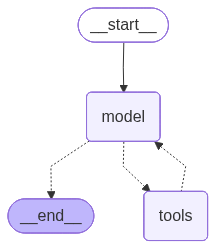

In [5]:
from langchain.agents import create_agent

def get_weather(city:str)-> str:
    """Get the weather for a city."""
    return f"The weather in {city} is sunny."

agent=create_agent(
    model="gpt-5",
    tools=[get_weather],
    system_prompt="You are a helpful assistant."
)
agent

In [8]:
### run the agent
response=agent.invoke({"messages":[{"role":"user","content":"What is the weather like in New York?"}]})

In [12]:
response["messages"]

[HumanMessage(content='What is the weather like in New York?', additional_kwargs={}, response_metadata={}, id='2ca5b95c-a5cf-4177-a607-b348c24dd1c1'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 88, 'prompt_tokens': 143, 'total_tokens': 231, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-Chtdqe90UhKBeTpbLXEFiYwBmWohg', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--afe3585e-2d18-4338-98e8-8842ed9fc1b3-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'New York'}, 'id': 'call_GPQVtdFPyMwdu1dRHq6s7wqw', 'type': 'tool_call'}], usage_metadata={'input_tokens': 143, 'output_tokens': 88, 'total_tokens': 231, 'inp

In [13]:
agent.invoke({"messages":"What is the weather in New Yourk"})

{'messages': [HumanMessage(content='What is the weather in New Yourk', additional_kwargs={}, response_metadata={}, id='733e1cb7-b8d2-4ac0-842e-69bb953a7b11'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 344, 'prompt_tokens': 142, 'total_tokens': 486, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 320, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-ChtehbQmmbhALfUhlHhnV81zZU2iR', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--ed5cedc8-2291-452f-83c9-c95c0993d254-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'New York'}, 'id': 'call_LYqCRNGlAnoxgfezQl01Vp2j', 'type': 'tool_call'}], usage_metadata={'input_tokens': 142, 'output_tokens': 344, 'total_tokens